In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
pabodhamallawa_dfuc2022_train_release_path = kagglehub.dataset_download('pabodhamallawa/dfuc2022-train-release')

print('Data source import complete.')


# Stabilizing Validation Performance

In the first baseline experiment, the U-Net model reached a best validation Dice score of around 0.619.  
However, the validation curve fluctuated across epochs.

This does not mean the model failed.  
Wound segmentation is naturally sensitive because many wound regions are very small compared with the full image.

From the previous analysis, the median wound area ratio was only around 1.09% of the full image.  
This means a small pixel-level prediction error can strongly affect Dice and IoU.

## Why Validation Fluctuates

Possible causes:

1. **Small wound regions**
   - Many wounds occupy only a tiny fraction of the image.
   - A slight mismatch between prediction and ground truth can cause a large Dice drop.

2. **High variation in wound appearance**
   - Some wounds are clearly visible.
   - Some wounds are small, dark, pale, surrounded by dry skin, or affected by lighting.

3. **Threshold sensitivity**
   - Dice/IoU are calculated after converting probabilities into binary masks.
   - Small changes around the threshold can change many pixels.

4. **Learning rate may be too aggressive**
   - The previous learning rate of `1e-3` helped the model learn quickly.
   - But later epochs showed validation instability.

5. **Validation split may not be balanced by wound size**
   - If the validation set contains many small or difficult wounds, the average metric can fluctuate.

## Strategy for This New Training Run

To make validation more stable, we will:

1. Rebuild the full setup from scratch because the session was stopped.
2. Use stratified train/validation split based on wound area ratio.
3. Lower the learning rate to `3e-4`.
4. Keep image size at `384 x 512` to preserve small wound details.
5. Use `BCEWithLogitsLoss + Dice Loss`.
6. Add gradient clipping.
7. Save the best checkpoint using validation Dice score.
8. Use early stopping if validation Dice does not improve.

## Goal

The goal is not to create a clinical-grade model.

The goal is to train a more stable baseline segmentation model for the hackathon demo:

Image → Wound Mask → Wound Area Ratio → Progression Tracking → Nurse Dashboard

In [ ]:
# Full setup cell: dataset, transforms, dataloaders, model, loss, optimizer

from pathlib import Path
import os
import random
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2


# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True


# ============================================================
# 2. Device and GPU check
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_AMP = torch.cuda.is_available()
MULTI_GPU = torch.cuda.is_available() and torch.cuda.device_count() > 1

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("Device         :", device)

if torch.cuda.is_available():
    print("Number of GPUs :", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")

print("AMP enabled    :", USE_AMP)
print("Multi-GPU      :", MULTI_GPU)


# ============================================================
# 3. Dataset paths
# ============================================================

IMAGE_DIR = Path("/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release/DFUC2022_train_images")
MASK_DIR  = Path("/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release/DFUC2022_train_masks")

print("\nImage directory exists:", IMAGE_DIR.exists())
print("Mask directory exists :", MASK_DIR.exists())

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

image_files = sorted([p for p in IMAGE_DIR.iterdir() if p.suffix.lower() in image_extensions])
mask_files  = sorted([p for p in MASK_DIR.iterdir() if p.suffix.lower() in image_extensions])

image_dict = {p.stem: p for p in image_files}
mask_dict  = {p.stem: p for p in mask_files}

common_ids = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

df = pd.DataFrame({
    "id": common_ids,
    "image_path": [str(image_dict[i]) for i in common_ids],
    "mask_path": [str(mask_dict[i]) for i in common_ids],
})

print("\nTotal matched samples:", len(df))
display(df.head())


# ============================================================
# 4. Compute wound area ratio for stratified split
# ============================================================

def compute_wound_ratio(mask_path):
    mask = Image.open(mask_path).convert("L")
    mask_np = np.array(mask)
    mask_bin = (mask_np > 0).astype(np.uint8)
    return float(mask_bin.mean())

print("\nComputing wound area ratio for stratified split...")

df["wound_ratio"] = [
    compute_wound_ratio(path) for path in tqdm(df["mask_path"], total=len(df))
]

print("\nWound ratio summary:")
display(df["wound_ratio"].describe())

# Create bins for stratification
# qcut balances the number of samples per bin.
df["wound_bin"] = pd.qcut(
    df["wound_ratio"],
    q=5,
    labels=False,
    duplicates="drop"
)

print("\nWound size bin distribution:")
display(df["wound_bin"].value_counts().sort_index())


# ============================================================
# 5. Stratified train/validation split
# ============================================================

train_df, valid_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
    stratify=df["wound_bin"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("\nDataset split")
print("Training samples  :", len(train_df))
print("Validation samples:", len(valid_df))

print("\nTrain wound ratio summary:")
display(train_df["wound_ratio"].describe())

print("\nValidation wound ratio summary:")
display(valid_df["wound_ratio"].describe())


# ============================================================
# 6. Transforms
# ============================================================

IMG_HEIGHT = 384
IMG_WIDTH = 512

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.08,
        rotate_limit=15,
        border_mode=0,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.5
    ),

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.10
    ),

    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

valid_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


# ============================================================
# 7. Dataset and DataLoader
# ============================================================

class DFUSegmentationDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        mask = Image.open(row["mask_path"]).convert("L")

        image = np.array(image)
        mask = np.array(mask)

        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        mask = mask.float()

        return {
            "image": image,
            "mask": mask,
            "id": row["id"]
        }


BATCH_SIZE = 16 if MULTI_GPU else 8
NUM_WORKERS = 2

train_dataset = DFUSegmentationDataset(train_df, transform=train_transform)
valid_dataset = DFUSegmentationDataset(valid_df, transform=valid_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

batch = next(iter(train_loader))

print("\nBatch check")
print("Image batch:", batch["image"].shape)
print("Mask batch :", batch["mask"].shape)
print("Mask range :", batch["mask"].min().item(), batch["mask"].max().item())


# ============================================================
# 8. U-Net model
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_channels // 2 + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=32):
        super().__init__()

        self.inc = DoubleConv(in_channels, base_channels)

        self.down1 = DownBlock(base_channels, base_channels * 2)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DownBlock(base_channels * 4, base_channels * 8)
        self.down4 = DownBlock(base_channels * 8, base_channels * 16)

        self.up1 = UpBlock(base_channels * 16, base_channels * 8, base_channels * 8)
        self.up2 = UpBlock(base_channels * 8, base_channels * 4, base_channels * 4)
        self.up3 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2)
        self.up4 = UpBlock(base_channels * 2, base_channels, base_channels)

        self.outc = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits


model = UNet(in_channels=3, out_channels=1, base_channels=32)
model = model.to(device)

if MULTI_GPU:
    model = nn.DataParallel(model)
    print("\nUsing DataParallel on", torch.cuda.device_count(), "GPUs")

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", f"{count_trainable_parameters(model):,}")


# ============================================================
# 9. Loss and metrics
# ============================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        denominator = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        loss = 1.0 - dice

        return loss.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=1.0, dice_weight=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)
        total_loss = self.bce_weight * bce_loss + self.dice_weight * dice_loss
        return total_loss, bce_loss.detach(), dice_loss.detach()


@torch.no_grad()
def compute_segmentation_metrics(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    pred_sum = preds.sum(dim=1)
    target_sum = targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (pred_sum + target_sum + smooth)
    iou = (intersection + smooth) / (pred_sum + target_sum - intersection + smooth)

    return dice.mean().item(), iou.mean().item()


criterion = BCEDiceLoss(bce_weight=1.0, dice_weight=1.0)


# ============================================================
# 10. Optimizer, scheduler, scaler, output
# ============================================================

EPOCHS = 30
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 8
METRIC_THRESHOLD = 0.5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

OUTPUT_DIR = Path("/kaggle/working/woundwatch_outputs_stable")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_DIR / "best_unet_dfuc2022_stable.pth"
LAST_MODEL_PATH = OUTPUT_DIR / "last_unet_dfuc2022_stable.pth"
HISTORY_PATH = OUTPUT_DIR / "training_history_stable.csv"

history = {
    "epoch": [],
    "train_loss": [],
    "train_dice": [],
    "train_iou": [],
    "valid_loss": [],
    "valid_dice": [],
    "valid_iou": [],
    "learning_rate": []
}

best_valid_dice = 0.0
epochs_without_improvement = 0

def get_current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

def get_model_state_dict(model):
    if isinstance(model, nn.DataParallel):
        return model.module.state_dict()
    return model.state_dict()

print("\nStable training setup is ready.")
print(f"Epochs             : {EPOCHS}")
print(f"Learning rate      : {LEARNING_RATE}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Image size         : {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"Gradient clipping  : {GRAD_CLIP_NORM}")
print(f"Early stopping     : {EARLY_STOPPING_PATIENCE}")
print(f"Best model path    : {BEST_MODEL_PATH}")

PyTorch version: 2.10.0+cu128
CUDA available : True
Device         : cuda
Number of GPUs : 2
GPU 0: Tesla T4
  Memory: 14.56 GB
GPU 1: Tesla T4
  Memory: 14.56 GB
AMP enabled    : True
Multi-GPU      : True

Image directory exists: True
Mask directory exists : True

Total matched samples: 2000


,id,image_path,mask_path
0,100001,/kaggle/input/datasets/pabodhamallawa/dfuc2022...,/kaggle/input/datasets/pabodhamallawa/dfuc2022...
1,100002,/kaggle/input/datasets/pabodhamallawa/dfuc2022...,/kaggle/input/datasets/pabodhamallawa/dfuc2022...
2,100003,/kaggle/input/datasets/pabodhamallawa/dfuc2022...,/kaggle/input/datasets/pabodhamallawa/dfuc2022...
3,100004,/kaggle/input/datasets/pabodhamallawa/dfuc2022...,/kaggle/input/datasets/pabodhamallawa/dfuc2022...
4,100005,/kaggle/input/datasets/pabodhamallawa/dfuc2022...,/kaggle/input/datasets/pabodhamallawa/dfuc2022...



Computing wound area ratio for stratified split...


  0%|          | 0/2000 [00:00<?, ?it/s]


Wound ratio summary:


...

count    1600.000000
mean        0.024256
std         0.037487
min         0.000391
25%         0.004697
50%         0.011003
75%         0.027332
max         0.350407
Name: wound_ratio, dtype: float64


Validation wound ratio summary:


count    400.000000
mean       0.024681
std        0.036164
min        0.000791
25%        0.004847
50%        0.010534
75%        0.026770
max        0.273210
Name: wound_ratio, dtype: float64

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



Batch check
Image batch: torch.Size([16, 3, 384, 512])
Mask batch : torch.Size([16, 1, 384, 512])
Mask range : 0.0 1.0

Using DataParallel on 2 GPUs
Trainable parameters: 7,763,041

Stable training setup is ready.
Epochs             : 30
Learning rate      : 0.0003
Batch size         : 16
Image size         : 384 x 512
Gradient clipping  : 1.0
Early stopping     : 8
Best model path    : /kaggle/working/woundwatch_outputs_stable/best_unet_dfuc2022_stable.pth


In [ ]:
# Stable training cell

def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device, use_amp=True):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    num_samples = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        batch_size = images.size(0)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            total_loss, bce_loss, dice_loss = criterion(logits, masks)

        scaler.scale(total_loss).backward()

        # Unscale before gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()

        dice_score, iou_score = compute_segmentation_metrics(
            logits.detach(),
            masks.detach(),
            threshold=METRIC_THRESHOLD
        )

        running_loss += total_loss.item() * batch_size
        running_dice += dice_score * batch_size
        running_iou += iou_score * batch_size
        num_samples += batch_size

        progress_bar.set_postfix({
            "loss": f"{total_loss.item():.4f}",
            "dice": f"{dice_score:.4f}",
            "iou": f"{iou_score:.4f}"
        })

    return (
        running_loss / num_samples,
        running_dice / num_samples,
        running_iou / num_samples
    )


@torch.no_grad()
def validate_one_epoch(model, dataloader, criterion, device, use_amp=True):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    num_samples = 0

    progress_bar = tqdm(dataloader, desc="Validation", leave=False)

    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        batch_size = images.size(0)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            total_loss, bce_loss, dice_loss = criterion(logits, masks)

        dice_score, iou_score = compute_segmentation_metrics(
            logits,
            masks,
            threshold=METRIC_THRESHOLD
        )

        running_loss += total_loss.item() * batch_size
        running_dice += dice_score * batch_size
        running_iou += iou_score * batch_size
        num_samples += batch_size

        progress_bar.set_postfix({
            "loss": f"{total_loss.item():.4f}",
            "dice": f"{dice_score:.4f}",
            "iou": f"{iou_score:.4f}"
        })

    return (
        running_loss / num_samples,
        running_dice / num_samples,
        running_iou / num_samples
    )


start_time = time.time()

print("Starting stable training...")
print(f"Total epochs: {EPOCHS}")
print(f"Initial LR  : {LEARNING_RATE}")
print(f"Threshold   : {METRIC_THRESHOLD}")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    print(f"\nEpoch [{epoch}/{EPOCHS}]")
    print(f"Learning rate: {get_current_lr(optimizer):.6f}")

    train_loss, train_dice, train_iou = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        use_amp=USE_AMP
    )

    valid_loss, valid_dice, valid_iou = validate_one_epoch(
        model=model,
        dataloader=valid_loader,
        criterion=criterion,
        device=device,
        use_amp=USE_AMP
    )

    scheduler.step(valid_loss)

    current_lr = get_current_lr(optimizer)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["train_iou"].append(train_iou)
    history["valid_loss"].append(valid_loss)
    history["valid_dice"].append(valid_dice)
    history["valid_iou"].append(valid_iou)
    history["learning_rate"].append(current_lr)

    is_best = valid_dice > best_valid_dice

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": get_model_state_dict(model),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_valid_dice": max(best_valid_dice, valid_dice),
        "history": history,
        "config": {
            "img_height": IMG_HEIGHT,
            "img_width": IMG_WIDTH,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "epochs": EPOCHS,
            "model": "UNet",
            "base_channels": 32,
            "loss": "BCEWithLogitsLoss + DiceLoss",
            "metric_threshold": METRIC_THRESHOLD,
            "split": "stratified_by_wound_area_ratio"
        }
    }

    torch.save(checkpoint, LAST_MODEL_PATH)

    if is_best:
        best_valid_dice = valid_dice
        epochs_without_improvement = 0
        torch.save(checkpoint, BEST_MODEL_PATH)
    else:
        epochs_without_improvement += 1

    history_df = pd.DataFrame(history)
    history_df.to_csv(HISTORY_PATH, index=False)

    epoch_time = time.time() - epoch_start

    print("-" * 70)
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Train IoU: {train_iou:.4f}"
    )
    print(
        f"Valid Loss: {valid_loss:.4f} | "
        f"Valid Dice: {valid_dice:.4f} | "
        f"Valid IoU: {valid_iou:.4f}"
    )
    print(f"Best Valid Dice: {best_valid_dice:.4f}")
    print(f"Epoch time: {epoch_time / 60:.2f} minutes")

    if is_best:
        print(f"New best model saved to: {BEST_MODEL_PATH}")

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        print(f"No validation Dice improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        break

total_time = time.time() - start_time

print("\nStable training finished.")
print(f"Total training time : {total_time / 60:.2f} minutes")
print(f"Best validation Dice: {best_valid_dice:.4f}")
print(f"Best model path     : {BEST_MODEL_PATH}")
print(f"Last model path     : {LAST_MODEL_PATH}")
print(f"History path        : {HISTORY_PATH}")

history_df = pd.DataFrame(history)
display(history_df)

Starting stable training...
Total epochs: 30
Initial LR  : 0.0003
Threshold   : 0.5
----------------------------------------------------------------------

Epoch [1/30]
Learning rate: 0.000300


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

----------------------------------------------------------------------
Train Loss: 1.3245 | Train Dice: 0.2303 | Train IoU: 0.1566
Valid Loss: 1.2171 | Valid Dice: 0.3561 | Valid IoU: 0.2604
Best Valid Dice: 0.3561
Epoch time: 3.50 minutes
New best model saved to: /kaggle/working/woundwatch_outputs_stable/best_unet_dfuc2022_stable.pth

Epoch [2/30]
Learning rate: 0.000300


Training:   0%|          | 0/100 [00:00<?, ?it/s]

...

----------------------------------------------------------------------
Train Loss: 0.3190 | Train Dice: 0.7358 | Train IoU: 0.6284
Valid Loss: 0.3712 | Valid Dice: 0.6852 | Valid IoU: 0.5834
Best Valid Dice: 0.6971
Epoch time: 5.32 minutes

Epoch [30/30]
Learning rate: 0.000150


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

----------------------------------------------------------------------
Train Loss: 0.3108 | Train Dice: 0.7419 | Train IoU: 0.6356
Valid Loss: 0.3700 | Valid Dice: 0.6850 | Valid IoU: 0.5815
Best Valid Dice: 0.6971
Epoch time: 2.96 minutes

Stable training finished.
Total training time : 98.62 minutes
Best validation Dice: 0.6971
Best model path     : /kaggle/working/woundwatch_outputs_stable/best_unet_dfuc2022_stable.pth
Last model path     : /kaggle/working/woundwatch_outputs_stable/last_unet_dfuc2022_stable.pth
History path        : /kaggle/working/woundwatch_outputs_stable/training_history_stable.csv


,epoch,train_loss,train_dice,train_iou,valid_loss,valid_dice,valid_iou,learning_rate
0,1,1.324486,0.230321,0.156562,1.217063,0.356110,0.260384,0.00030
1,2,1.166547,0.371780,0.270546,1.199821,0.291785,0.191760,0.00030
2,3,1.067426,0.443167,0.332214,1.012170,0.479802,0.367714,0.00030
3,4,0.976648,0.489221,0.369954,0.942410,0.489466,0.388723,0.00030
4,5,0.899869,0.503668,0.382636,0.867992,0.454127,0.333900,0.00030
5,6,0.823725,0.526621,0.405045,0.795324,0.522716,0.407764,0.00030
6,7,0.758473,0.542983,0.419525,0.709444,0.568167,0.457004,0.00030
7,8,0.697490,0.563257,0.442120,0.660696,0.567116,0.446473,0.00030
8,9,0.638270,0.580420,0.458858,0.593959,0.606959,0.486555,0.00030
9,10,0.587406,0.598085,0.477362,0.575884,0.573531,0.453259,0.00030


## Reconstructing Training History After Session Reset

The Kaggle session has stopped, but the training results were preserved in tabular form.

To continue the analysis, we can manually reconstruct the training history as a dataframe from the saved epoch-level metrics.

This allows us to:

- Recover the training history without rerunning training
- Identify the best validation epoch
- Plot loss, Dice, IoU, and learning rate curves
- Use the plots in the notebook and final presentation

This step is useful for experiment tracking, especially when the session is interrupted.

In [ ]:
import pandas as pd

history_data = [
    [1, 1.324486, 0.230321, 0.156562, 1.217063, 0.356110, 0.260384, 0.00030],
    [2, 1.166547, 0.371780, 0.270546, 1.199821, 0.291785, 0.191760, 0.00030],
    [3, 1.067426, 0.443167, 0.332214, 1.012170, 0.479802, 0.367714, 0.00030],
    [4, 0.976648, 0.489221, 0.369954, 0.942410, 0.489466, 0.388723, 0.00030],
    [5, 0.899869, 0.503668, 0.382636, 0.867992, 0.454127, 0.333900, 0.00030],
    [6, 0.823725, 0.526621, 0.405045, 0.795324, 0.522716, 0.407764, 0.00030],
    [7, 0.758473, 0.542983, 0.419525, 0.709444, 0.568167, 0.457004, 0.00030],
    [8, 0.697490, 0.563257, 0.442120, 0.660696, 0.567116, 0.446473, 0.00030],
    [9, 0.638270, 0.580420, 0.458858, 0.593959, 0.606959, 0.486555, 0.00030],
    [10, 0.587406, 0.598085, 0.477362, 0.575884, 0.573531, 0.453259, 0.00030],
    [11, 0.547327, 0.611344, 0.490835, 0.587093, 0.594805, 0.483288, 0.00030],
    [12, 0.524607, 0.618731, 0.497816, 0.541532, 0.596856, 0.480845, 0.00030],
    [13, 0.490621, 0.632972, 0.515502, 0.485121, 0.623886, 0.508814, 0.00030],
    [14, 0.473154, 0.638713, 0.521475, 0.461579, 0.636180, 0.519951, 0.00030],
    [15, 0.455258, 0.648015, 0.531629, 0.461190, 0.627461, 0.513640, 0.00030],
    [16, 0.445305, 0.647814, 0.531356, 0.455478, 0.636821, 0.527387, 0.00030],
    [17, 0.435545, 0.654502, 0.538937, 0.450986, 0.633863, 0.520447, 0.00030],
    [18, 0.415427, 0.665900, 0.550625, 0.427226, 0.647261, 0.533917, 0.00030],
    [19, 0.415750, 0.665265, 0.551463, 0.401527, 0.669418, 0.556746, 0.00030],
    [20, 0.394599, 0.679180, 0.567033, 0.417896, 0.657188, 0.547907, 0.00030],
    [21, 0.395623, 0.676284, 0.563170, 0.464162, 0.614490, 0.498633, 0.00030],
    [22, 0.383417, 0.684972, 0.573176, 0.403857, 0.661691, 0.549039, 0.00030],
    [23, 0.370713, 0.695535, 0.582169, 0.406729, 0.656111, 0.556549, 0.00015],
    [24, 0.343747, 0.716720, 0.606230, 0.382939, 0.678992, 0.571732, 0.00015],
    [25, 0.342949, 0.718302, 0.608917, 0.384618, 0.677470, 0.569926, 0.00015],
    [26, 0.332949, 0.725142, 0.616766, 0.391891, 0.666586, 0.565002, 0.00015],
    [27, 0.328906, 0.727758, 0.620306, 0.381616, 0.676804, 0.574166, 0.00015],
    [28, 0.321886, 0.732069, 0.625530, 0.360866, 0.697053, 0.591936, 0.00015],
    [29, 0.318983, 0.735751, 0.628358, 0.371241, 0.685223, 0.583403, 0.00015],
    [30, 0.310797, 0.741887, 0.635650, 0.370028, 0.685013, 0.581507, 0.00015],
]

history_df = pd.DataFrame(
    history_data,
    columns=[
        "epoch",
        "train_loss",
        "train_dice",
        "train_iou",
        "valid_loss",
        "valid_dice",
        "valid_iou",
        "learning_rate",
    ]
)

display(history_df.head())
print("Total epochs:", len(history_df))

,epoch,train_loss,train_dice,train_iou,valid_loss,valid_dice,valid_iou,learning_rate
0,1,1.324486,0.230321,0.156562,1.217063,0.356110,0.260384,0.0003
1,2,1.166547,0.371780,0.270546,1.199821,0.291785,0.191760,0.0003
2,3,1.067426,0.443167,0.332214,1.012170,0.479802,0.367714,0.0003
3,4,0.976648,0.489221,0.369954,0.942410,0.489466,0.388723,0.0003
4,5,0.899869,0.503668,0.382636,0.867992,0.454127,0.333900,0.0003


Total epochs: 30


In [ ]:
import matplotlib.pyplot as plt

# หา best epoch จาก validation dice
best_idx = history_df["valid_dice"].idxmax()
best_row = history_df.loc[best_idx]

print("Best model summary")
print(f"Best epoch      : {int(best_row['epoch'])}")
print(f"Best valid Dice : {best_row['valid_dice']:.4f}")
print(f"Best valid IoU  : {best_row['valid_iou']:.4f}")
print(f"Valid loss      : {best_row['valid_loss']:.4f}")
print(f"Learning rate   : {best_row['learning_rate']:.6f}")

Best model summary
Best epoch      : 28
Best valid Dice : 0.6971
Best valid IoU  : 0.5919
Valid loss      : 0.3609
Learning rate   : 0.000150


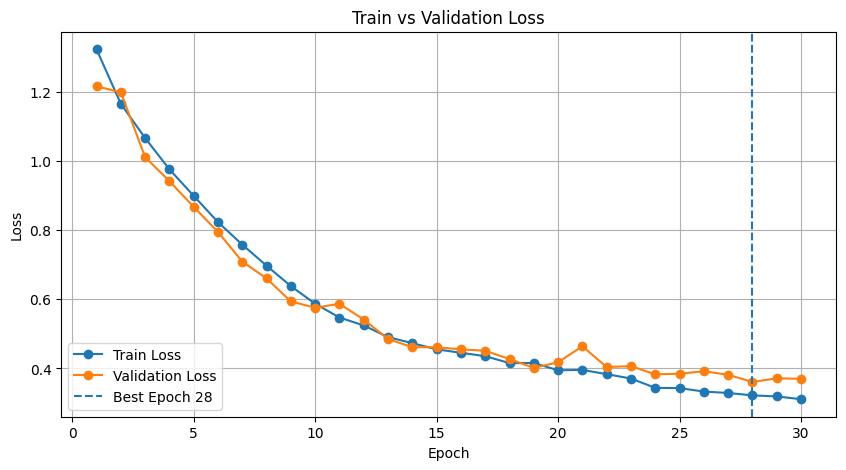

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], marker="o", label="Validation Loss")
plt.axvline(best_row["epoch"], linestyle="--", label=f"Best Epoch {int(best_row['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

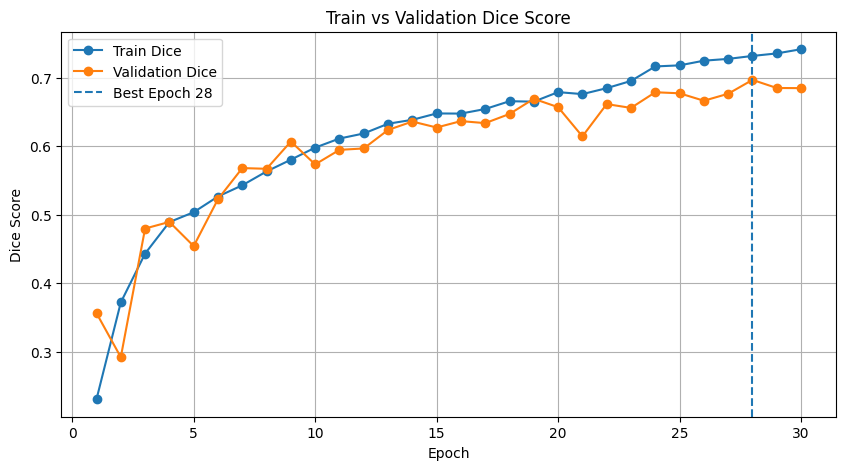

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_dice"], marker="o", label="Train Dice")
plt.plot(history_df["epoch"], history_df["valid_dice"], marker="o", label="Validation Dice")
plt.axvline(best_row["epoch"], linestyle="--", label=f"Best Epoch {int(best_row['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Train vs Validation Dice Score")
plt.legend()
plt.grid(True)
plt.show()

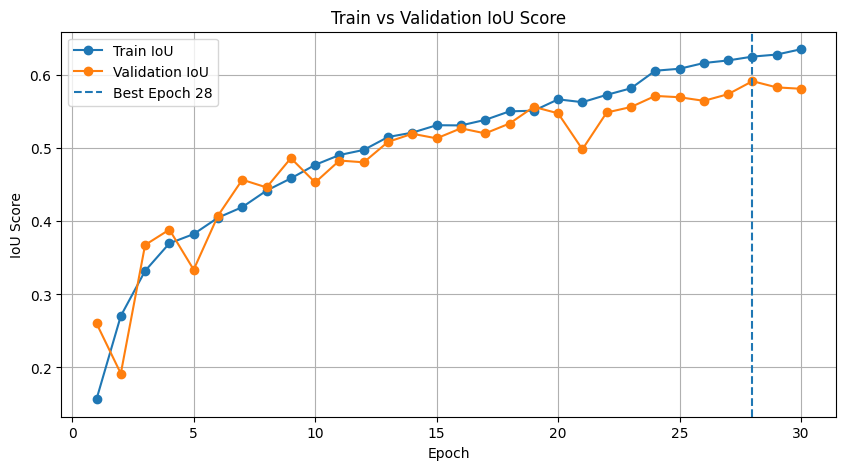

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_iou"], marker="o", label="Train IoU")
plt.plot(history_df["epoch"], history_df["valid_iou"], marker="o", label="Validation IoU")
plt.axvline(best_row["epoch"], linestyle="--", label=f"Best Epoch {int(best_row['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.title("Train vs Validation IoU Score")
plt.legend()
plt.grid(True)
plt.show()

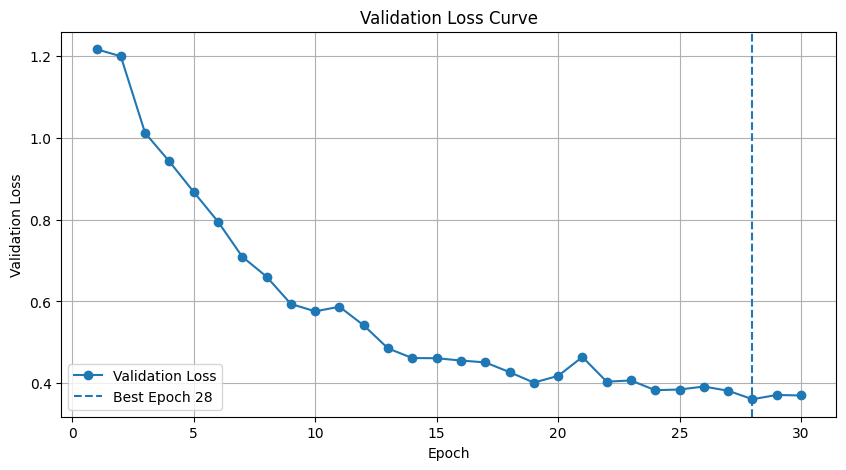

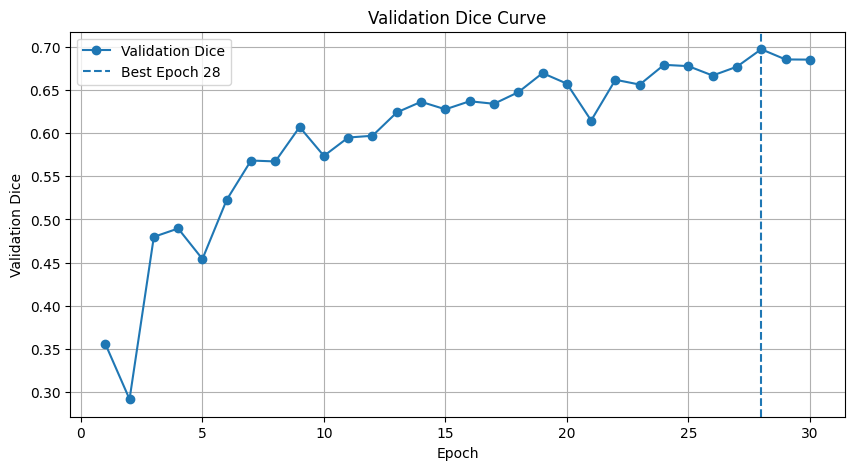

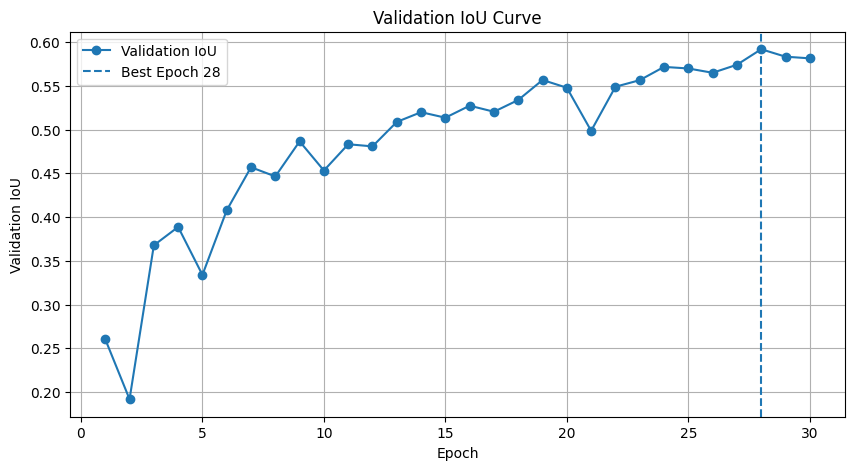

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["valid_loss"], marker="o", label="Validation Loss")
plt.axvline(best_row["epoch"], linestyle="--", label=f"Best Epoch {int(best_row['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["valid_dice"], marker="o", label="Validation Dice")
plt.axvline(best_row["epoch"], linestyle="--", label=f"Best Epoch {int(best_row['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("Validation Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["valid_iou"], marker="o", label="Validation IoU")
plt.axvline(best_row["epoch"], linestyle="--", label=f"Best Epoch {int(best_row['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Validation IoU")
plt.title("Validation IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

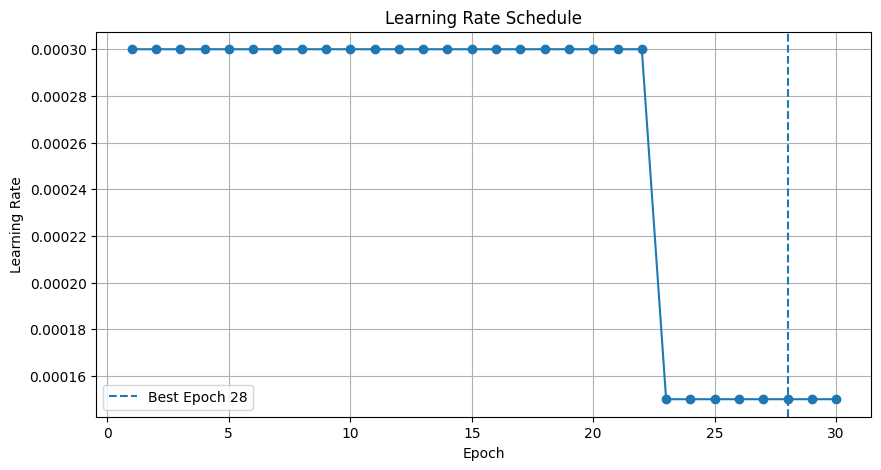

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["learning_rate"], marker="o")
plt.axvline(best_row["epoch"], linestyle="--", label=f"Best Epoch {int(best_row['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

## Result Summary

After reconstructing the training history from the saved results, the stabilized training experiment shows a clear improvement over the earlier baseline run.

### Best validation performance
- Best Epoch: 28
- Best Validation Dice: 0.6971
- Best Validation IoU: 0.5919
- Validation Loss at best epoch: 0.3609

### Interpretation
The validation curves are more stable than in the first experiment, and the best validation Dice score improved substantially.

This suggests that the stabilization strategy worked:

- lower learning rate
- stratified split by wound area ratio
- gradient clipping
- longer training schedule
